#  Non-Parametric Naive Bayes Classifier

- **Naive Bayes** assumes conditional independence between features:
  $$
  P(y \mid \mathbf{x}) \propto P(y) \prod_{i=1}^d P(x_i \mid y)
  $$

- In the **non-parametric version**, we estimate $ P(x_i \mid y) $ using:
  - **Histograms/frequencies** for discrete features.
  - **KDE** for continuous features.

- We do **not** assume any fixed distribution (e.g., Gaussian, Bernoulli).


In [ ]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#from Competion1Functions import *   

In [72]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from scipy.stats import gaussian_kde
from collections import defaultdict
from scipy.stats import norm

# Plot KDE for a feature split by class

def plot_kde_feature(X, y, feature_index):
    plt.figure(figsize=(6, 4))
    for cls in np.unique(y):
        sns.kdeplot(X[y == cls, feature_index], label=f"Class {cls}")
    plt.title(f"KDE of Feature {feature_index}")
    plt.legend()
    plt.show()


# Histogram Naive Bayes Classifier for discrete features
# This is a simple implementation of Naive Bayes using histograms for density estimation.

class HistogramNaiveBayes:
    def __init__(self, bins=10, smoothing=1e-3):
        self.bins = bins
        self.smoothing = smoothing
        self.histograms = defaultdict(dict)
        self.class_priors = {}
        self.classes = None

    def fit(self, X, y):
        self.classes = np.unique(y)
        n = len(y)

        for cls in self.classes:
            X_cls = X[y == cls]
            self.class_priors[cls] = len(X_cls) / n

            for i in range(X.shape[1]):
                hist, bin_edges = np.histogram(X_cls[:, i], bins=self.bins, density=False)
                # Add smoothing
                self.histograms[cls][i] = (hist + self.smoothing, bin_edges)

    def predict_proba(self, X):
        results = []
        for x in X:
            log_probs = {}
            for cls in self.classes:
                log_prob = np.log(self.class_priors[cls])
                for i, val in enumerate(x):
                    hist, bin_edges = self.histograms[cls][i]
                    bin_idx = np.digitize(val, bin_edges) - 1
                    bin_idx = np.clip(bin_idx, 0, len(hist) - 1)
                    prob = hist[bin_idx] / np.sum(hist)
                    log_prob += np.log(prob + 1e-9)
                log_probs[cls] = log_prob
            # Normalize via softmax trick
            max_log = max(log_probs.values())
            exp_scores = {k: np.exp(v - max_log) for k, v in log_probs.items()}
            total = sum(exp_scores.values())
            results.append({k: v / total for k, v in exp_scores.items()})
        return results

    def predict(self, X):
        proba = self.predict_proba(X)
        return [max(p, key=p.get) for p in proba]

# Model NonParametricNaiveBayes with tunable KDE bandwidth and option to choose from Gaussian or Epanechnikov kernels.

# Custom Epanechnikov KDE
def epanechnikov_kernel(u):
    return 0.75 * (1 - u**2) * (np.abs(u) <= 1) # Epanechnikov kernel function

class EpanechnikovKDE:
    def __init__(self, data, bandwidth=1.0):
        self.data = np.asarray(data)
        self.bandwidth = bandwidth
        self.n = len(data)

    def evaluate(self, x):
        x = np.atleast_1d(x) # Ensure x is an array
        estimates = np.zeros_like(x, dtype=float) # Initialize estimates
        # Iterate over each point in x
        for i, xi in enumerate(x):  
            u = (xi - self.data) / self.bandwidth # Calculate the scaled distance
            kernels = epanechnikov_kernel(u) # Apply the Epanechnikov kernel
            estimates[i] = np.sum(kernels) # Sum the kernel values
        return estimates / (self.n * self.bandwidth) # Normalize by n and bandwidth
 
class NonParametricNaiveBayes: 
    def __init__(self, bandwidth=1.0, kernel='gaussian'): # Gaussian KDE bandwidth (for later tuning)
        """
        Non-parametric Naive Bayes classifier using Gaussian KDE for density estimation.
        Parameters:
            - bandwidth: smoothing parameter for KDE.
            - kernel: 'gaussian' or 'epanechnikov'.
        """
        self.bandwidth = bandwidth 
        self.kernel = kernel.lower()
        self.kdes = defaultdict(dict) # KDEs for each class and feature
        self.class_priors = {} 
        self.classes = None # Class labels

    def _create_kde(self, data):
        if self.kernel == 'gaussian':
            return gaussian_kde(data, bw_method=self.bandwidth)
        elif self.kernel == 'epanechnikov':
            return EpanechnikovKDE(data, bandwidth=self.bandwidth)
        else:
            raise ValueError(f"Unsupported kernel: {self.kernel}")

    def fit(self, X, y):
        self.classes = np.unique(y) # Unique class labels
        n = len(y) # Total number of samples
        
        for cls in self.classes: # Iterate over each class
            X_cls = X[y == cls] # Samples for the current class
            self.class_priors[cls] = len(X_cls) / n # Class prior probability

            # Fit KDE for each feature in the class
            for feature_idx in range(X.shape[1]): 
                kde = self._create_kde(X_cls[:, feature_idx]) # Apply KDE
                self.kdes[cls][feature_idx] = kde # Store 

    def predict_proba(self, X): # Predict class probabilities for each sample
        probs = [] # Store in list
        for x in X: # Iterate over each sample
            # Calculate log probabilities for each class
            class_scores = {} # Store log probabilities

            # Iterate over each class and calculate the log probability
            for cls in self.classes:
                log_prob = np.log(self.class_priors[cls]) # Start with the log prior

                # Iterate over each feature and calculate the log probability
                for feature_idx, val in enumerate(x):
                    kde = self.kdes[cls][feature_idx] # Get the KDE for the current class and feature
                    p = kde.evaluate(val)[0] + 1e-9 # Avoid log(0) by adding a small value
                    log_prob += np.log(p) # Log probability of the feature given the class
                class_scores[cls] = log_prob # Store the log probability for the current class
            # Softmax trick
            max_log = max(class_scores.values()) # For numerical stability
            exp_scores = {k: np.exp(v - max_log) for k, v in class_scores.items()} # Exponentiate the log probabilities
            total = sum(exp_scores.values()) # Sum of exponentiated scores
            probs.append({k: v / total for k, v in exp_scores.items()}) # Normalize to get probabilities
        return probs

    def predict(self, X):
        proba = self.predict_proba(X) # Get class probabilities
        return [max(p, key=p.get) for p in proba] # Return the class with the highest probability
    
def tune_bandwidth(X, y, bandwidths, kernel='gaussian'):
    """
    Tune the bandwidth hyperparameter for NonParametricNaiveBayes.

    Parameters:
    - X, y: training data and labels
    - bandwidths: iterable of bandwidth values to try
    - kernel: 'gaussian' or 'epanechnikov'
    """

    skf = StratifiedKFold(n_splits=3)
    best_bw = None
    best_acc = 0

    for bw in bandwidths:
        accs = []
        for train_idx, val_idx in skf.split(X, y):
            model = NonParametricNaiveBayes(bandwidth=bw, kernel=kernel)
            model.fit(X[train_idx], y[train_idx])
            preds = model.predict(X[val_idx])
            accs.append(accuracy_score(y[val_idx], preds))
        avg = np.mean(accs)
        print(f"Kernel={kernel:<12} | Bandwidth={bw:.2f} -> CV Accuracy: {avg:.4f}")
        if avg > best_acc:
            best_acc = avg
            best_bw = bw

    print(f"\n✅ Best Bandwidth for {kernel.upper()}: {best_bw}")
    return best_bw

def epanechnikov_kernel(u):
    return 0.75 * (1 - u**2) * (np.abs(u) <= 1)

def gaussian_kernel(u):
    return norm.pdf(u)


X shape: (2000, 20)
y shape: (2000,)


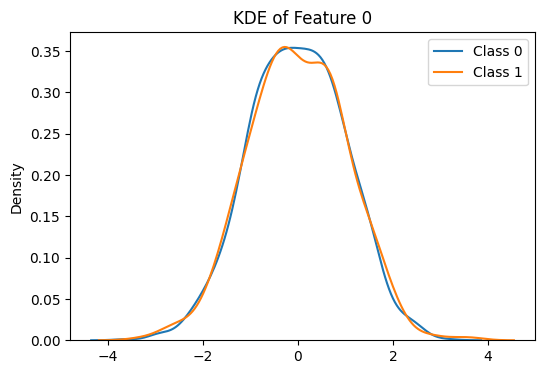

In [26]:
# Synthetic dataset of quite complexity
X, y = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=5,
    n_redundant=5,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=2,
    weights=[0.7, 0.3],          # Class imbalance
    flip_y=0.1,                  # Add label noise
    class_sep=0.8,               # Low separation
    random_state=42
)


# Quick preview
print("X shape:", X.shape)
print("y shape:", y.shape)

# Plot KDE for a feature split by class
plot_kde_feature(X, y, feature_index=0)

### Feature Ranking (Univariate Mutual Info)

Syntetic data may have redundant info (like I added in my case), so we deal with it beforehand to make the model less complicate and reduce computational time. This may also bring greater results if those features actually confuse the model itself

    Feature  MI Score
2         2  0.084576
9         9  0.079743
16       16  0.070101
17       17  0.066936
13       13  0.050703
18       18  0.031961
12       12  0.031675
14       14  0.023682
6         6  0.015447
8         8  0.013814
1         1  0.008931
7         7  0.008412
10       10  0.007584
11       11  0.004076
0         0  0.003798
15       15  0.000000
5         5  0.000000
4         4  0.000000
3         3  0.000000
19       19  0.000000


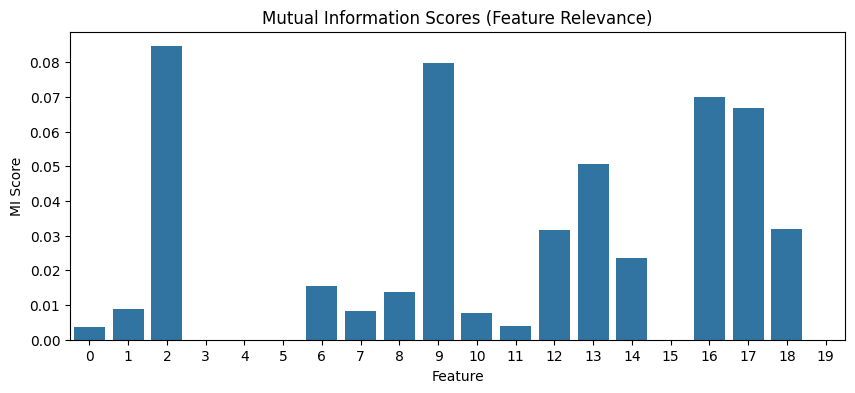

In [27]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

mi_scores = mutual_info_classif(X, y)
mi_df = pd.DataFrame({'Feature': np.arange(len(mi_scores)), 'MI Score': mi_scores})
mi_df = mi_df.sort_values(by='MI Score', ascending=False)
print(mi_df)
plt.figure(figsize=(10, 4))
sns.barplot(data=mi_df, x='Feature', y='MI Score')
plt.title("Mutual Information Scores (Feature Relevance)")
plt.show()

In [ ]:
# Optionale
selected_features = mi_df['Feature'].values[mi_df['MI Score'] >= 0.001]  # Select features with MI score >= 0.1
X = X[:, selected_features] # We just keep those to make the dataset lighter

## Histogram-Based Naive Bayes Classifier

Is a **non-parametric classifier** that estimates the conditional probability $ P(x_i \mid y) $ using **binned frequency counts** (histograms) rather than assuming a fixed probability distribution like Gaussian. It's a good approximation of KDE (in the discrete form)

##### Core Idea

For each feature and class, we build a **histogram**:
- Divide the feature range into `B` bins.
- Count how many training samples fall in each bin.
- Normalize to get conditional probabilities.

Given a new sample x, we compute:
$$
P(y \mid x) \propto P(y) \prod_{i=1}^{d} P(x_i \in \text{bin}_j \mid y)
$$

We use **Laplace (additive) smoothing** to prevent zero probabilities.

##### Key Hyperparameters

| Hyperparameter | Description                           |
|----------------|---------------------------------------|
| `bins`         | Number of bins used for histograms    |
| `smoothing`    | Additive smoothing for stability      |


##### ⚠️ Limitations

- Bin size selection is crucial
- Discontinuous decision boundary (hard edges)
- Sensitive to feature scaling (always standardize)


In [39]:
from sklearn.model_selection import train_test_split
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train/test model
hist_nb = HistogramNaiveBayes(bins=12, smoothing=1e-3)
hist_nb.fit(X_train, y_train)
y_pred_hist = hist_nb.predict(X_test)

# Evaluate
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(" Histogram-Based Naive Bayes Performance:")
print(classification_report(y_test, y_pred_hist))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_hist))
print("Accuracy:", accuracy_score(y_test, y_pred_hist))


 Histogram-Based Naive Bayes Performance:
              precision    recall  f1-score   support

           0       0.74      0.92      0.82       263
           1       0.73      0.39      0.50       137

    accuracy                           0.74       400
   macro avg       0.73      0.66      0.66       400
weighted avg       0.74      0.74      0.71       400

Confusion Matrix:
 [[243  20]
 [ 84  53]]
Accuracy: 0.74


### Joint Tuning for Bins and Smoothing

to tune both bins and smoothing together

In [ ]:
# Try combinations of bins and smoothing
from itertools import product # all combinations of parameters
from sklearn.model_selection import StratifiedKFold

best_score = 0
best_params = None

for bins, smooth in product(range(5, 31, 5), [1e-3, 1e-2, 1e-1]):
    scores = []
    skf = StratifiedKFold(n_splits=3) # CV
    # Loop over folds
    for train_idx, val_idx in skf.split(X_train, y_train): 
        model = HistogramNaiveBayes(bins=bins, smoothing=smooth) # reinitialize model
        model.fit(X_train[train_idx], y_train[train_idx]) # fit on train fold
        y_pred = model.predict(X_train[val_idx]) # predict on val fold
        scores.append(accuracy_score(y_train[val_idx], y_pred)) # evaluate and store
    avg_score = np.mean(scores)
    print(f"Bins={bins}, Smoothing={smooth} → Acc={avg_score:.4f}") 
    if avg_score > best_score:
        best_score = avg_score
        best_params = (bins, smooth)

print("\n✅ Best Parameters:", best_params)


Bins=5, Smoothing=0.001 → Acc=0.7119
Bins=5, Smoothing=0.01 → Acc=0.7119
Bins=5, Smoothing=0.1 → Acc=0.7125
Bins=10, Smoothing=0.001 → Acc=0.7238
Bins=10, Smoothing=0.01 → Acc=0.7244
Bins=10, Smoothing=0.1 → Acc=0.7244
Bins=15, Smoothing=0.001 → Acc=0.7269
Bins=15, Smoothing=0.01 → Acc=0.7275
Bins=15, Smoothing=0.1 → Acc=0.7287
Bins=20, Smoothing=0.001 → Acc=0.7262
Bins=20, Smoothing=0.01 → Acc=0.7281
Bins=20, Smoothing=0.1 → Acc=0.7287
Bins=25, Smoothing=0.001 → Acc=0.7275
Bins=25, Smoothing=0.01 → Acc=0.7294
Bins=25, Smoothing=0.1 → Acc=0.7300
Bins=30, Smoothing=0.001 → Acc=0.7262
Bins=30, Smoothing=0.01 → Acc=0.7306
Bins=30, Smoothing=0.1 → Acc=0.7281

✅ Best Parameters: (30, 0.01)


In [50]:
# Train final model on the entire training set with best bin count
hist_nb_final = HistogramNaiveBayes(bins=best_params[0], smoothing=best_params[1])
hist_nb_final.fit(X_train, y_train)
y_pred_final = hist_nb_final.predict(X_test)

# Evaluate final model
from sklearn.metrics import classification_report, accuracy_score
print("Final Model Evaluation:")
print(classification_report(y_test, y_pred_final))
print("Accuracy:", accuracy_score(y_test, y_pred_final))

Final Model Evaluation:
              precision    recall  f1-score   support

           0       0.72      0.93      0.81       263
           1       0.70      0.31      0.43       137

    accuracy                           0.72       400
   macro avg       0.71      0.62      0.62       400
weighted avg       0.72      0.72      0.68       400

Accuracy: 0.72


Attention: Score may depends a lot by the split, CV helps in this case but still it's not enough to overcome a possible overfit, it still depends by the split used. Not worth to overcome this issue but it's important to take it into consideration

## Kernel Density Estimation (KDE)

KDE estimates the probability density of a variable \( x \) without assuming a fixed distribution:
$$
\hat{f}(x) = \frac{1}{n h} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)
$$

- h: Bandwidth (controls smoothness)
- K: Kernel function (e.g., Gaussian)

KDE is used here to estimate the **conditional probability** $ P(x_i \mid y) $ for each class and each feature.


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
nb_kde = NonParametricNaiveBayes(bandwidth=0.3)
nb_kde.fit(X_train, y_train)

# Predict
y_pred = nb_kde.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.74

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.79      0.80       263
           1       0.62      0.64      0.63       137

    accuracy                           0.74       400
   macro avg       0.71      0.72      0.71       400
weighted avg       0.74      0.74      0.74       400


Confusion Matrix:
 [[208  55]
 [ 49  88]]


### Tuning the Bandwidth

- **A small bandwidth leads to undersmoothing.**
It means that the density plot will look like a combination of individual peeks (one peek per each sample element).

- **A huge bandwidth leads to oversmoothing.**
It means that the density plot will look like a unimodal distribution and hide all non-unimodal distribution properties (e.g., if a distribution is multimodal, we will not see it in the plot).

The right parameter allow us to maximize the performance of our model in our specific case

[Here is detailed explanation](https://aakinshin.net/posts/kde-bw/)

In [ ]:
bw_range = np.linspace(0.1, 1.0, 10) # Range of values to try
best_bw_gauss = tune_bandwidth(X_train, y_train, bw_range, kernel='gaussian')
print(f"Best bandwidth: {best_bw_gauss:.2f}")

BW=0.10 -> ACC=0.7370
BW=0.20 -> ACC=0.7395
BW=0.30 -> ACC=0.7370
BW=0.40 -> ACC=0.7315
BW=0.50 -> ACC=0.7290
BW=0.60 -> ACC=0.7265
BW=0.70 -> ACC=0.7230
BW=0.80 -> ACC=0.7255
BW=0.90 -> ACC=0.7235
BW=1.00 -> ACC=0.7220

Best Bandwidth: 0.2
Best bandwidth: 0.20


### Threshold Tweaking for Imbalance (To review only if needed)

This scenario may probably happen so switching the threshold in the way of the unbalance class may overcome some limitation in our Training set in the case we have not enough sample of the smaller class and our model decides to put more confidence into the majority class

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

def tune_threshold(y_true, y_proba, metric='f1', thresholds=np.linspace(0.1, 0.9, 50)):
    scores = []
    for t in thresholds:
        y_pred = [1 if p[1] > t else 0 for p in y_proba]
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
        acc = accuracy_score(y_true, y_pred)
        scores.append({
            'threshold': t,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'accuracy': acc
        })

    scores_df = pd.DataFrame(scores) # df easier


    # Find best threshold for selected metric
    best_row = scores_df.loc[scores_df[metric].idxmax()]
    print(f"Best threshold for {metric.upper()}: {best_row['threshold']:.2f} → {metric} = {best_row[metric]:.4f}")
    return best_row['threshold'], scores_df

# Usage
y_proba = nb_kde.predict_proba(X_test)
best_thresh, scores_df = tune_threshold(y_test, y_proba, metric='f1')



Bandwidth 0.10 -> Accuracy: 0.7300
Bandwidth 0.33 -> Accuracy: 0.7293
Bandwidth 0.55 -> Accuracy: 0.7336
Bandwidth 0.78 -> Accuracy: 0.7271
Bandwidth 1.00 -> Accuracy: 0.7300

✅ Best bandwidth: 0.55


In [ ]:
# Predict using best threshold
y_final = [1 if p[1] > best_thresh else 0 for p in y_proba]

from sklearn.metrics import classification_report
print("Classification Report with Optimized Threshold:")
print(classification_report(y_test, y_final))

### Other Kernel Functions for Density Estimation

##### 🔹 Gaussian Kernel (Infinite support)
$$
K(u) = \frac{1}{\sqrt{2\pi}} e^{-\frac{u^2}{2}}
$$
- Smooth, bell-shaped
- Has infinite support (tails go forever)

##### 🔹 Epanechnikov Kernel (Compact support)
$$
K(u) = \frac{3}{4}(1 - u^2) \quad \text{if } |u| \leq 1, \text{ else } 0
$$
- Finite support: only affects neighbors within 1 bandwidth
- Computationally faster
- Often **optimal in MSE** under some assumptions

---


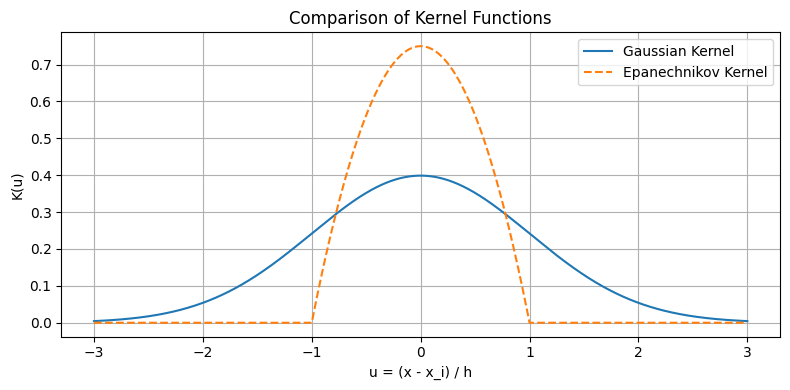

In [ ]:
u = np.linspace(-3, 3, 1000)
# Compute kernel values
ep_values = epanechnikov_kernel(u)
gauss_values = gaussian_kernel(u)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(u, gauss_values, label='Gaussian Kernel')
plt.plot(u, ep_values, label='Epanechnikov Kernel', linestyle='--')
plt.title("Comparison of Kernel Functions")
plt.xlabel("u = (x - x_i) / h")
plt.ylabel("K(u)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [55]:
# Custom Epanechnikov KDE
def epanechnikov_kernel(u):
    return 0.75 * (1 - u**2) * (np.abs(u) <= 1) # Epanechnikov kernel function

class EpanechnikovKDE:
    def __init__(self, data, bandwidth=1.0):
        self.data = np.asarray(data)
        self.bandwidth = bandwidth
        self.n = len(data)

    def evaluate(self, x):
        x = np.atleast_1d(x) # Ensure x is an array
        estimates = np.zeros_like(x, dtype=float) # Initialize estimates
        # Iterate over each point in x
        for i, xi in enumerate(x):  
            u = (xi - self.data) / self.bandwidth # Calculate the scaled distance
            kernels = epanechnikov_kernel(u) # Apply the Epanechnikov kernel
            estimates[i] = np.sum(kernels) # Sum the kernel values
        return estimates / (self.n * self.bandwidth) # Normalize by n and bandwidth
 
class NonParametricNaiveBayes: 
    def __init__(self, bandwidth=1.0, kernel='gaussian'): # Gaussian KDE bandwidth (for later tuning)
        """
        Non-parametric Naive Bayes classifier using Gaussian KDE for density estimation.
        Parameters:
            - bandwidth: smoothing parameter for KDE.
            - kernel: 'gaussian' or 'epanechnikov'.
        """
        self.bandwidth = bandwidth 
        self.kernel = kernel.lower()
        self.kdes = defaultdict(dict) # KDEs for each class and feature
        self.class_priors = {} 
        self.classes = None # Class labels

    def _create_kde(self, data):
        if self.kernel == 'gaussian':
            return gaussian_kde(data, bw_method=self.bandwidth)
        elif self.kernel == 'epanechnikov':
            return EpanechnikovKDE(data, bandwidth=self.bandwidth)
        else:
            raise ValueError(f"Unsupported kernel: {self.kernel}")

    def fit(self, X, y):
        self.classes = np.unique(y) # Unique class labels
        n = len(y) # Total number of samples
        
        for cls in self.classes: # Iterate over each class
            X_cls = X[y == cls] # Samples for the current class
            self.class_priors[cls] = len(X_cls) / n # Class prior probability

            # Fit KDE for each feature in the class
            for feature_idx in range(X.shape[1]): 
                kde = self._create_kde(X_cls[:, feature_idx]) # Apply KDE
                self.kdes[cls][feature_idx] = kde # Store 

    def predict_proba(self, X): # Predict class probabilities for each sample
        probs = [] # Store in list
        for x in X: # Iterate over each sample
            # Calculate log probabilities for each class
            class_scores = {} # Store log probabilities

            # Iterate over each class and calculate the log probability
            for cls in self.classes:
                log_prob = np.log(self.class_priors[cls]) # Start with the log prior

                # Iterate over each feature and calculate the log probability
                for feature_idx, val in enumerate(x):
                    kde = self.kdes[cls][feature_idx] # Get the KDE for the current class and feature
                    p = kde.evaluate(val)[0] + 1e-9 # Avoid log(0) by adding a small value
                    log_prob += np.log(p) # Log probability of the feature given the class
                class_scores[cls] = log_prob # Store the log probability for the current class
            # Softmax trick
            max_log = max(class_scores.values()) # For numerical stability
            exp_scores = {k: np.exp(v - max_log) for k, v in class_scores.items()} # Exponentiate the log probabilities
            total = sum(exp_scores.values()) # Sum of exponentiated scores
            probs.append({k: v / total for k, v in exp_scores.items()}) # Normalize to get probabilities
        return probs

    def predict(self, X):
        proba = self.predict_proba(X) # Get class probabilities
        return [max(p, key=p.get) for p in proba] # Return the class with the highest probability

In [56]:
# Train with Epanechnikov kernel
epan_nb = NonParametricNaiveBayes(bandwidth=0.3, kernel='epanechnikov')
epan_nb.fit(X_train, y_train)
y_pred_e = epan_nb.predict(X_test)

print("📘 Epanechnikov KDE Naive Bayes:")
print(classification_report(y_test, y_pred_e))
print("Accuracy:", accuracy_score(y_test, y_pred_e))


📘 Epanechnikov KDE Naive Bayes:
              precision    recall  f1-score   support

           0       0.79      0.78      0.79       263
           1       0.59      0.61      0.60       137

    accuracy                           0.72       400
   macro avg       0.69      0.70      0.69       400
weighted avg       0.73      0.72      0.72       400

Accuracy: 0.7225


In [57]:
def tune_bandwidth(X, y, bandwidths, kernel='gaussian'):
    """
    Tune the bandwidth hyperparameter for NonParametricNaiveBayes.

    Parameters:
    - X, y: training data and labels
    - bandwidths: iterable of bandwidth values to try
    - kernel: 'gaussian' or 'epanechnikov'
    """

    skf = StratifiedKFold(n_splits=3)
    best_bw = None
    best_acc = 0

    for bw in bandwidths:
        accs = []
        for train_idx, val_idx in skf.split(X, y):
            model = NonParametricNaiveBayes(bandwidth=bw, kernel=kernel)
            model.fit(X[train_idx], y[train_idx])
            preds = model.predict(X[val_idx])
            accs.append(accuracy_score(y[val_idx], preds))
        avg = np.mean(accs)
        print(f"Kernel={kernel:<12} | Bandwidth={bw:.2f} -> CV Accuracy: {avg:.4f}")
        if avg > best_acc:
            best_acc = avg
            best_bw = bw

    print(f"\n✅ Best Bandwidth for {kernel.upper()}: {best_bw}")
    return best_bw


In [59]:
bw_range = np.linspace(0.1, 1.0, 10) # Range of values to try
best_bw_epan = tune_bandwidth(X_train, y_train, bw_range, kernel='epanechnikov')
print(f"Best bandwidth: {best_bw_epan:.2f}")

Kernel=epanechnikov | Bandwidth=0.10 -> CV Accuracy: 0.7325
Kernel=epanechnikov | Bandwidth=0.20 -> CV Accuracy: 0.7356
Kernel=epanechnikov | Bandwidth=0.30 -> CV Accuracy: 0.7363
Kernel=epanechnikov | Bandwidth=0.40 -> CV Accuracy: 0.7338
Kernel=epanechnikov | Bandwidth=0.50 -> CV Accuracy: 0.7356
Kernel=epanechnikov | Bandwidth=0.60 -> CV Accuracy: 0.7350
Kernel=epanechnikov | Bandwidth=0.70 -> CV Accuracy: 0.7331
Kernel=epanechnikov | Bandwidth=0.80 -> CV Accuracy: 0.7338
Kernel=epanechnikov | Bandwidth=0.90 -> CV Accuracy: 0.7350
Kernel=epanechnikov | Bandwidth=1.00 -> CV Accuracy: 0.7331

✅ Best Bandwidth for EPANECHNIKOV: 0.30000000000000004
Best bandwidth: 0.30


In [60]:
from sklearn.decomposition import PCA

# Riduci i dati a 2D
pca = PCA(n_components=2)
X_train_2D = pca.fit_transform(X_train)
X_test_2D = pca.transform(X_test)


In [ ]:
# Scegli il kernel che vuoi provare: 'gaussian' o 'epanechnikov'
#model_2D = NonParametricNaiveBayes(bandwidth=0.3, kernel='epanechnikov')
model_2D = NonParametricNaiveBayes(bandwidth=0.3, kernel='gaussian')
model_2D.fit(X_train_2D, y_train)


In [62]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    h = 0.02  # step size in mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict over grid
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = np.array(model.predict(grid))
    Z = Z.reshape(xx.shape)

    # Plotting
    plt.figure(figsize=(8, 6))
    cmap_light = ListedColormap(['#FFBBBB', '#BBBBFF'])
    cmap_bold = ListedColormap(['#FF0000', '#0000FF'])
    
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.5)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=30)
    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
0.55

0.48052631578947375

In [73]:
# Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix) # eigh is used for symmetric matrices, it returns eigenvalues
idx = eigenvalues.argsort()[::-1] # Sort eigenvalues in descending order
eigenvalues = eigenvalues[idx] # Reorder eigenvalues based on the sorted index
eigenvectors = eigenvectors[:, idx] # Reorder eigenvectors  accordingly

# Project Data onto First Two Principal Components
W = eigenvectors[:, :2]  # Select the first two eigenvectors
projected_data = centered_data @ W # Project the data onto the first two eigenvectors

# Plotting Principal Components
origin = np.mean(projected_data, axis=0)  # Origin for PCA arrows

# Plot data points
plt.figure(figsize=(10, 8))
for i, species in enumerate(target_names):
    plt.scatter(projected_data[target == i, 0], 
                projected_data[target == i, 1], 
                label=species, alpha=0.7)

# Plot principal component arrows
for i in range(2):
    plt.arrow(origin[0], origin[1], 
              W[0, i] * eigenvalues[i], W[1, i] * eigenvalues[i],
              color='r' if i == 0 else 'g', 
              width=0.05, label=f'PC{i+1}')

plt.title('Principal Components of the Iris Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


NameError: name 'cov_matrix' is not defined